Deep Learning

In [113]:
import numpy as np
import pandas as pd

import seaborn as sns

In [114]:
df=pd.read_csv('fake_reg.csv')

In [115]:
df.head(5)

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


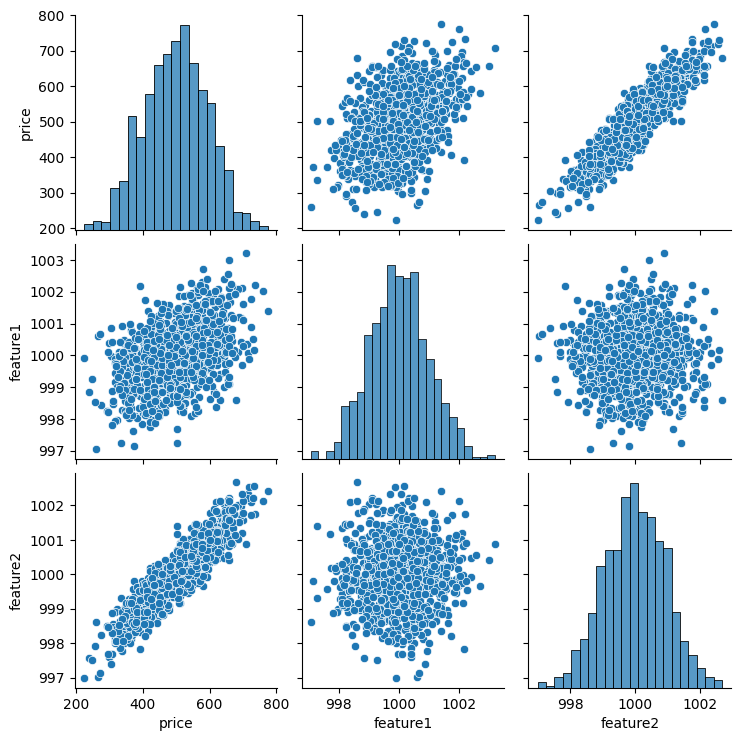

In [116]:
sns.pairplot(df)

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X=df[['feature1','feature2']].values

In [119]:
y=df['price'].values

In [120]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=101)

In [121]:
from sklearn.preprocessing import MinMaxScaler

In [122]:
scaler=MinMaxScaler()

In [123]:
scaler.fit(X_train)

MinMaxScaler()

In [124]:
X_train=scaler.transform(X_train)

In [125]:
X_test=scaler.transform(X_test)

In [126]:
# %pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [127]:
# help(Sequential)

In [128]:
model=Sequential([Dense(4,activation='relu'),Dense(4,activation='relu'),Dense(4,activation='relu'),Dense(1)])

In [129]:
model.compile(optimizer='rmsprop',loss='mse')

In [130]:
model.fit(x=X_train,y=y_train,epochs=250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 254921.0469   
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 257275.3594 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 263293.5625 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 259162.9375 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255185.1406 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255454.7656 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 254518.5938
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 254562.8594
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255806.8594 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 261742.8125 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 252780.2500 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 262996.9375 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256017.3438 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 

In [131]:
loss_df=pd.DataFrame(model.history.history)

<Axes: >

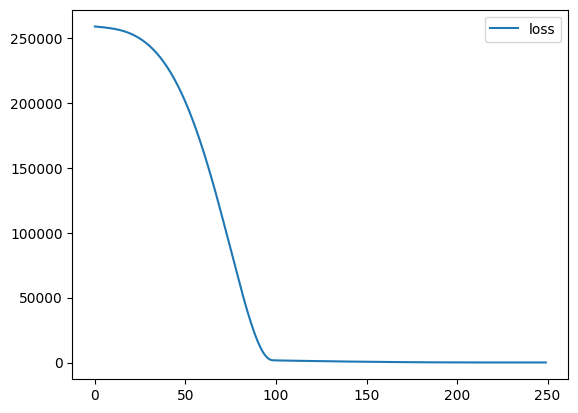

In [132]:
loss_df.plot()

In [133]:
model.evaluate(X_test,y_test,verbose=0)

27.413082122802734

In [134]:
model.evaluate(X_train,y_train,verbose=0)

23.140684127807617

In [135]:
test_predictions=model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [136]:
# test_predictions

In [137]:
test_predictions=pd.Series(test_predictions.reshape(300,))

In [138]:
pred_df=pd.DataFrame(y_test,columns=['Test True Y'])

In [139]:
pred_df=pd.concat([pred_df,test_predictions],axis=1)

In [140]:
pred_df.columns=['Test True Y','Model Predictions']

<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

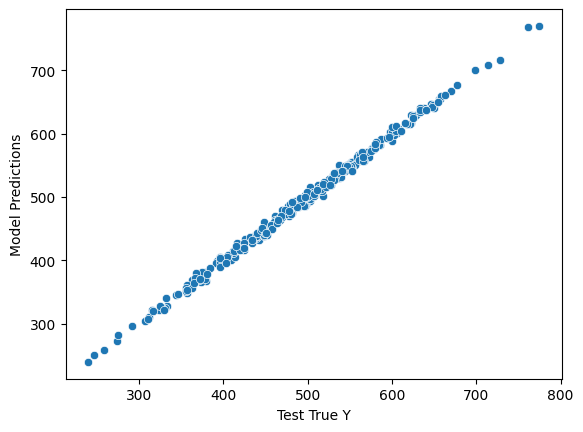

In [141]:
sns.scatterplot(x='Test True Y', y='Model Predictions',data=pred_df)

In [142]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [143]:
mean_absolute_error(pred_df['Test True Y'],pred_df['Model Predictions'])

4.190726175985581

In [144]:
df.describe()

,price,feature1,feature2
count,1000.000000,1000.000000,1000.000000
mean,498.673029,1000.014171,999.979847
std,93.785431,0.974018,0.948330
min,223.346793,997.058347,996.995651
25%,433.025732,999.332068,999.316106
50%,502.382117,1000.009915,1000.002243
75%,564.921588,1000.637580,1000.645380
max,774.407854,1003.207934,1002.666308


In [145]:
mean_squared_error(pred_df['Test True Y'],pred_df['Model Predictions'])**0.5

5.235750638296498

In [146]:
new_gem=[[998,1000]]

In [147]:
new_gem=scaler.transform(new_gem)

In [148]:
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[419.60614]], dtype=float32)

In [149]:
from tensorflow.keras.models import load_model

In [150]:
model.save('my_model.h5')

In [152]:
from tensorflow.keras import metrics
later_model=load_model('my_model.h5', custom_objects={'mse': metrics.MeanSquaredError()})

In [153]:
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


array([[419.60614]], dtype=float32)